# Lab 05 - Bài tập

## THÔNG TIN SINH VIÊN

- Họ tên: Nguyễn Nam Trung Nguyên
- MSV:23640731


Sinh viên ghi số bài làm được vào ô dưới đây:

## KẾT QUẢ: 4/4 bài

---

### Bài 1. Phân Phối Đều – Thời Gian Chờ Xe Buýt

Xe buýt tuyến 36 (TP.HCM) xuất phát đều đặn mỗi **20 phút** một chuyến.
Một hành khách đến bến vào thời điểm ngẫu nhiên, nên thời gian chờ $X \sim U(0, 20)$ (phút).

**Câu hỏi:**

1. Tính xác suất hành khách chờ **dưới 8 phút**: $P(X < 8)$.
2. Tính xác suất hành khách chờ **từ 5 đến 15 phút**: $P(5 \le X \le 15)$.
3. Tính **thời gian chờ trung bình** và **độ lệch chuẩn**.
4. Sinh 5,000 mẫu từ $U(0,20)$, vẽ histogram kèm đường pdf lý thuyết,
   tô màu vùng $[5, 15]$ và so sánh xác suất thực nghiệm với lý thuyết.


1.Xác xuất hành khách chờ dưới 8 phút:         0.4
2.Xác xuất hành khách chờ từ 5 đến 15 phút:    0.5
3.Thời gian chờ trung bình(Mean):              10.0
  Độ lệch chuẩn(Standard Deviation):           5.773502691896258
4.Biểu đồ


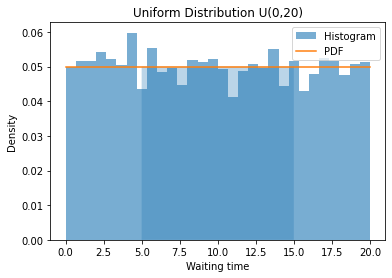

Xác xuất Lý thuyết:  0.5
Xác suất thực nghiệm:  0.4936
Kết luận: Hai kết quả gần nhau. vậy mô hình đúng


In [1]:
# YOUR CODE HERE
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
# Bài 1.1
a = 0
b = 20
P = (8- a) / (b - a)
print("1.Xác xuất hành khách chờ dưới 8 phút:        ", P)

# Bài 1.2
P = (15-5) / (b-a)
print("2.Xác xuất hành khách chờ từ 5 đến 15 phút:   ", P)

# Bài 1.3
mean = (a+b)/2
std = (b-a)/math.sqrt(12)
print("3.Thời gian chờ trung bình(Mean):             ", mean)
print("  Độ lệch chuẩn(Standard Deviation):          ", std)

# Bài 1.4
print("4.Biểu đồ")
n = 5000
data = np.random.uniform(0,20,n)

plt.hist(data, bins=30, density=True, alpha=0.6, label="Histogram")
x = np.linspace(0, 20, 1000)
pdf = uniform.pdf(x, 0, 20)
plt.plot(x, pdf, label="PDF")

x_fill = np.linspace(5, 15, 1000)
plt.fill_between(x_fill, uniform.pdf(x_fill, 0, 20), alpha=0.3)

plt.title("Uniform Distribution U(0,20)")
plt.xlabel("Waiting time")
plt.ylabel("Density")
plt.legend()
plt.show()
empirical_prob = np.mean((data >= 5) & (data <= 15))
print("Xác xuất Lý thuyết: ", P)
print("Xác suất thực nghiệm: ", empirical_prob)
print("Kết luận: Hai kết quả gần nhau. vậy mô hình đúng")

### Bài 2. Phân Phối Chuẩn – Kiểm Soát Chất Lượng Đóng Gói

Một nhà máy thực phẩm đóng gói mì ăn liền với khối lượng mỗi gói
$X \sim N(\mu = 75\text{ g},\ \sigma^2 = 4\text{ g}^2)$.
Tiêu chuẩn chất lượng yêu cầu khối lượng mỗi gói nằm trong khoảng $[73\text{ g},\ 77\text{ g}]$.

**Câu hỏi:**

1. Tính **tỷ lệ sản phẩm đạt chuẩn** $P(73 \le X \le 77)$.
2. Tính **tỷ lệ sản phẩm lỗi** (ngoài khoảng cho phép).
3. Nếu mỗi ngày sản xuất **100,000 gói**, ước tính số gói bị lỗi mỗi ngày.
4. Ban quản lý muốn tỷ lệ lỗi không vượt quá **0.5%**. Giữ nguyên $\mu = 75$ g,
   cần điều chỉnh $\sigma$ xuống bao nhiêu?
5. Vẽ đường pdf và tô màu hai vùng lỗi (dưới 73 g và trên 77 g).


1.Tỷ lệ sản phẩm đạt chuẩn 𝑃(73≤𝑋≤77):         0.6826894921370859
2.Tỷ lệ sản phẩm lỗi (ngoài khoảng cho phép):  0.31731050786291415
3.Số gói lỗi mỗi ngày:                         31731
4.Sigma cần đạt:                               0.7124958817934093
5.Biểu đồ đường pdf và tô màu hai vùng lỗi (dưới 73 g và trên 77 g):


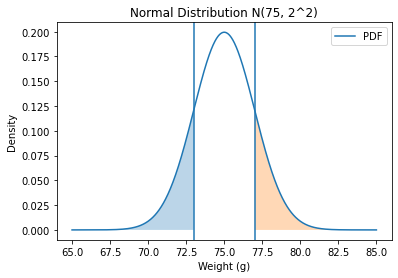

In [2]:
# YOUR CODE HERE
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# Bài 2.1
mu = 75
sigma = 2

p = norm.cdf(77, mu, sigma) - norm.cdf(73, mu, sigma)
print("1.Tỷ lệ sản phẩm đạt chuẩn 𝑃(73≤𝑋≤77):        ", p)

# Bài 2.2 
p_defect = 1 - p
print("2.Tỷ lệ sản phẩm lỗi (ngoài khoảng cho phép): ", p_defect)

# Bài 2.3
total = 100000
defect_count = total * p_defect

print("3.Số gói lỗi mỗi ngày:                        ", int(defect_count))
# Bài 2.4
target = 0.995
z = norm.ppf((1 + target) / 2)

sigma_new = 2 / z
print("4.Sigma cần đạt:                              ", sigma_new)

# Bài 2.5
print("5.Biểu đồ đường pdf và tô màu hai vùng lỗi (dưới 73 g và trên 77 g):")
x = np.linspace(65, 85, 1000)
pdf = norm.pdf(x, mu, sigma)

# Vẽ pdf
plt.plot(x, pdf, label="PDF")

# Tô vùng lỗi bên trái (<73)
x_left = np.linspace(65, 73, 300)
plt.fill_between(x_left, norm.pdf(x_left, mu, sigma), alpha=0.3)

# Tô vùng lỗi bên phải (>77)
x_right = np.linspace(77, 85, 300)
plt.fill_between(x_right, norm.pdf(x_right, mu, sigma), alpha=0.3)

# Vẽ đường giới hạn
plt.axvline(73)
plt.axvline(77)

plt.title("Normal Distribution N(75, 2^2)")
plt.xlabel("Weight (g)")
plt.ylabel("Density")
plt.legend()
plt.show()

### Bài 3. Phân Phối Student t – Đánh Giá Thời Gian Giao Hàng

Một sàn thương mại điện tử lấy mẫu **12 đơn hàng** ngẫu nhiên và ghi lại
thời gian giao hàng (tính bằng giờ):

```
data = [22, 25, 19, 28, 24, 30, 21, 26, 23, 27, 20, 29]
```

Giả sử thời gian giao hàng có phân phối chuẩn, **phương sai tổng thể chưa biết**.

**Câu hỏi:**

1. Tính trung bình mẫu $\bar{x}$ và độ lệch chuẩn mẫu $s$.
2. Xác định **phân phối của thống kê kiểm định** $T = \dfrac{\bar{X}-\mu_0}{s/\sqrt{n}}$ với $n=12$.
3. Tính $P(T > 1.5)$ với phân phối t tương ứng.
4. Tìm giá trị tới hạn $t_{0.025, 11}$ (hai phía, mức ý nghĩa 5%).
5. Vẽ đường pdf của $t(11)$, đánh dấu giá trị tới hạn và tô màu vùng bác bỏ hai phía.


**YOUR ANSWER HERE:**

1.Trung bình mẫu(Mean):                   24.5
  Độ lệch chuẩn(Sample Std):              3.605551275463989
2.Phân phối của thống kê kiểm định:       T ~ t(11)
3.P(T > 1.5):                             0.080879008527727
4.Giá trị tới hạn t_0.025,11:             2.200985160082949
5.Vẽ đường pdf của 𝑡(11), đánh dấu giá trị tới hạn và tô màu vùng bác bỏ hai phía:


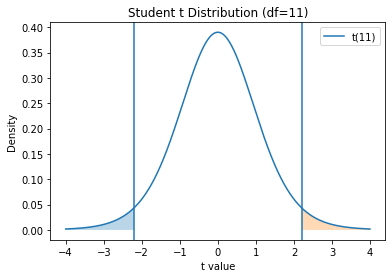

In [3]:
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

data = [22, 25, 19, 28, 24, 30, 21, 26, 23, 27, 20, 29]

# Bài 3.1
n = len(data)
df = n - 1
mean = np.mean(data)
std = np.std(data, ddof=1)

print("1.Trung bình mẫu(Mean):                  ", mean)
print("  Độ lệch chuẩn(Sample Std):             ", std)

# Bài 3.2
print(f"2.Phân phối của thống kê kiểm định:       T ~ t({df})")

# Bài 3.3
p_value = 1 - t.cdf(1.5, df)

print("3.P(T > 1.5):                            ", p_value)

t_crit = t.ppf(1 - 0.025, df)

# Bài 3.4
print("4.Giá trị tới hạn t_0.025,11:            ", t_crit)

# Bài 3.5
print("5.Vẽ đường pdf của 𝑡(11), đánh dấu giá trị tới hạn và tô màu vùng bác bỏ hai phía:")
x = np.linspace(-4, 4, 1000)
pdf = t.pdf(x, df)

plt.plot(x, pdf, label="t(11)")

# Tô vùng bác bỏ bên trái
x_left = np.linspace(-4, -t_crit, 200)
plt.fill_between(x_left, t.pdf(x_left, df), alpha=0.3)

# Tô vùng bác bỏ bên phải
x_right = np.linspace(t_crit, 4, 200)
plt.fill_between(x_right, t.pdf(x_right, df), alpha=0.3)

# Vẽ đường giới hạn
plt.axvline(-t_crit)
plt.axvline(t_crit)

plt.title("Student t Distribution (df=11)")
plt.xlabel("t value")
plt.ylabel("Density")
plt.legend()

plt.show()

### Bài 4. Phân Phối Chi-square – Kiểm Định Độ Ổn Định Sản Xuất

Một dây chuyền sản xuất chip điện tử được coi là ổn định nếu **phương sai** điện áp
đầu ra $\sigma^2 \le 0.04\ (\text{V}^2)$. Kỹ sư lấy mẫu $n = 25$ chip và tính được
$s^2 = 0.052\ \text{V}^2$.

Thống kê kiểm định:
$$\chi^2 = \frac{(n-1)s^2}{\sigma_0^2} \sim \chi^2(n-1)$$

**Câu hỏi:**

1. Tính **giá trị thống kê** $\chi^2_{obs}$ với $n=25$, $s^2=0.052$, $\sigma_0^2=0.04$.
2. Tính **p-value** (kiểm định một phía, $H_1: \sigma^2 > 0.04$):
   $p = P(\chi^2_{24} \ge \chi^2_{obs})$.
3. Tìm giá trị tới hạn $\chi^2_{0.95, 24}$ (mức ý nghĩa $\alpha = 0.05$).
4. Kết luận: dây chuyền có ổn định không ở mức ý nghĩa 5%?
5. Vẽ đường pdf của $\chi^2(24)$, tô màu vùng bác bỏ và đánh dấu $\chi^2_{obs}$.

> 💡 *Gợi ý:* Dùng `stats.chi2(df=24)` với các hàm `cdf`, `sf`, `ppf`.

1.Giá trị thống kê χ²_obs:                31.2
2.p-value (kiểm định 1 phía):             0.14809930158518575
3.Giá trị tới hạn χ²_0.95,24:             36.41502850180731
4.Kết luận kiểm định:
  → Không bác bỏ H0: Dây chuyền ổn định
5.Vẽ đường pdf của χ²(24), tô vùng bác bỏ và đánh dấu χ²_obs:


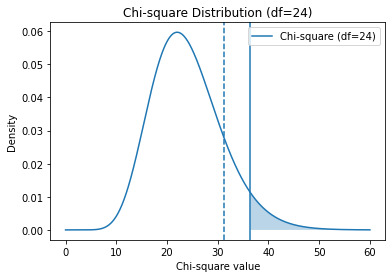

In [4]:
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Dữ liệu
n = 25
s2 = 0.052
sigma0_2 = 0.04
df = n - 1 

# Bài 4.1
chi2_obs = (df * s2) / sigma0_2

print("1.Giá trị thống kê χ²_obs:               ", chi2_obs)

p_value = chi2.sf(chi2_obs, df)

print("2.p-value (kiểm định 1 phía):            ", p_value)

# ================================
# Bài 4.3
# ================================
alpha = 0.05
chi2_crit = chi2.ppf(1 - alpha, df)

print("3.Giá trị tới hạn χ²_0.95,24:            ", chi2_crit)

# Bài 4.4
print("4.Kết luận kiểm định:")

if chi2_obs > chi2_crit:
    print("  → Bác bỏ H0: Dây chuyền KHÔNG ổn định")
else:
    print("  → Không bác bỏ H0: Dây chuyền ổn định")

# Bài 4.5
print("5.Vẽ đường pdf của χ²(24), tô vùng bác bỏ và đánh dấu χ²_obs:")

x = np.linspace(0, 60, 1000)
pdf = chi2.pdf(x, df)

plt.plot(x, pdf, label="Chi-square (df=24)")

x_fill = np.linspace(chi2_crit, 60, 300)
plt.fill_between(x_fill, chi2.pdf(x_fill, df), alpha=0.3)

plt.axvline(chi2_crit)

plt.axvline(chi2_obs, linestyle='--')

plt.title("Chi-square Distribution (df=24)")
plt.xlabel("Chi-square value")
plt.ylabel("Density")
plt.legend()

plt.show()

=========================== Lab  Completed ===========================

---

## CHANGELOG

- 20260316: add new version
- ...

---